# Hyperparameter Tuning - XGBoost & Random Forest

This notebook fine-tunes the two best-performing models from baseline comparison:
- XGBoost
- Random Forest

We use RandomizedSearchCV for efficient hyperparameter search and track all experiments with MLflow.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from src.feature_engineering import feature_engineering

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Preparation

Load the engineered features and apply the same feature selection as in baseline training.

In [2]:
# Load preprocessed data from feature engineering pipeline
X_train, X_val, X_test, y_train, y_val, y_test, scaler = feature_engineering()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set: 81393 samples, 212 features
Validation set: 10174 samples
Test set: 10175 samples

Class distribution in training set:
readmitted
0    0.5391
1    0.4609
Name: proportion, dtype: float64


In [3]:
# Feature selection using Random Forest importance (same as baseline)
# This ensures consistency with baseline experiments

# Group one-hot encoded columns by their base category
groups = {}
for col in X_train.columns:
    base = re.sub(r'_[^_]+$', '', col)
    groups.setdefault(base, []).append(col)

# Train a quick RF to get feature importances
selector_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
selector_model.fit(X_train, y_train)

# Select top 25 features, but include all columns from same categorical group
importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(25).index

final_features = set()
for g, cols in groups.items():
    if any(c in top_features for c in cols):
        final_features.update(cols)

# Apply feature selection to all sets
X_train = X_train[list(final_features)]
X_val = X_val[list(final_features)]
X_test = X_test[list(final_features)]

print(f"Selected {len(final_features)} features after grouping")

Selected 180 features after grouping


In [4]:
# Clean column names for XGBoost compatibility
for df in [X_train, X_val, X_test]:
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]

print("Column names cleaned for XGBoost compatibility")

Column names cleaned for XGBoost compatibility


## 2. MLflow Setup

In [5]:
# Configure MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("hyperparameter-tuning")

print("MLflow configured. Tracking URI: http://localhost:5000")
print("Experiment: hyperparameter-tuning")

MLflow configured. Tracking URI: http://localhost:5000
Experiment: hyperparameter-tuning


## 3. Define Hyperparameter Search Spaces

We define reasonable ranges for each hyperparameter based on common best practices.

In [6]:
# XGBoost hyperparameter search space
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1, 2, 3]  # helps with class imbalance
}

# Random Forest hyperparameter search space
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# Number of random combinations to try
N_ITER = 15
CV_FOLDS = 2

print(f"Search configuration:")
print(f"  - Random iterations: {N_ITER}")
print(f"  - CV folds: {CV_FOLDS}")

Search configuration:
  - Random iterations: 15
  - CV folds: 2


## 4. XGBoost Hyperparameter Tuning

In [7]:
print("Starting XGBoost hyperparameter tuning...")
print("="*50)

with mlflow.start_run(run_name="XGBoost_Tuning"):
    # Log search configuration
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("search_type", "RandomizedSearchCV")
    mlflow.log_param("n_iter", N_ITER)
    mlflow.log_param("cv_folds", CV_FOLDS)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "tuning")
    
    # Initialize base model
    xgb_base = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    # Randomized search with cross-validation
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_grid,
        n_iter=N_ITER,
        scoring='f1',  # optimize for F1 score
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=4,
        verbose=1
    )
    
    # Fit on training data
    xgb_search.fit(X_train, y_train)
    
    # Get best model and parameters
    best_xgb = xgb_search.best_estimator_
    best_xgb_params = xgb_search.best_params_
    
    # Log best hyperparameters
    for param, value in best_xgb_params.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    xgb_val_pred = best_xgb.predict(X_val)
    xgb_val_proba = best_xgb.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    xgb_metrics = {
        'accuracy': accuracy_score(y_val, xgb_val_pred),
        'f1': f1_score(y_val, xgb_val_pred),
        'precision': precision_score(y_val, xgb_val_pred),
        'recall': recall_score(y_val, xgb_val_pred),
        'roc_auc': roc_auc_score(y_val, xgb_val_proba),
        'cv_best_score': xgb_search.best_score_
    }
    
    # Log metrics
    for metric_name, metric_value in xgb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the tuned model
    mlflow.xgboost.log_model(best_xgb, "xgboost_tuned")
    
    print(f"\nBest XGBoost Parameters:")
    for param, value in best_xgb_params.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in xgb_metrics.items():
        print(f"  {metric}: {value:.4f}")

Starting XGBoost hyperparameter tuning...
Fitting 2 folds for each of 15 candidates, totalling 30 fits


2026/01/07 15:24:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/07 15:24:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best XGBoost Parameters:
  subsample: 0.7
  scale_pos_weight: 2
  n_estimators: 200
  min_child_weight: 3
  max_depth: 3
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 0.9

Validation Metrics:
  accuracy: 0.5656
  f1: 0.6540
  precision: 0.5166
  recall: 0.8910
  roc_auc: 0.6858
  cv_best_score: 0.6570
🏃 View run XGBoost_Tuning at: http://localhost:5000/#/experiments/956909141126980178/runs/241490d6950f4d1e8b3dd8c5ddbafdb7
🧪 View experiment at: http://localhost:5000/#/experiments/956909141126980178


## 5. Random Forest Hyperparameter Tuning

In [8]:
print("Starting Random Forest hyperparameter tuning...")
print("="*50)

with mlflow.start_run(run_name="RandomForest_Tuning"):
    # Log search configuration
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("search_type", "RandomizedSearchCV")
    mlflow.log_param("n_iter", N_ITER)
    mlflow.log_param("cv_folds", CV_FOLDS)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "tuning")
    
    # Initialize base model
    rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
    
    # Randomized search with cross-validation
    rf_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_param_grid,
        n_iter=N_ITER,
        scoring='f1',
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=4,
        verbose=1
    )
    
    # Fit on training data
    rf_search.fit(X_train, y_train)
    
    # Get best model and parameters
    best_rf = rf_search.best_estimator_
    best_rf_params = rf_search.best_params_
    
    # Log best hyperparameters
    for param, value in best_rf_params.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    rf_val_pred = best_rf.predict(X_val)
    rf_val_proba = best_rf.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    rf_metrics = {
        'accuracy': accuracy_score(y_val, rf_val_pred),
        'f1': f1_score(y_val, rf_val_pred),
        'precision': precision_score(y_val, rf_val_pred),
        'recall': recall_score(y_val, rf_val_pred),
        'roc_auc': roc_auc_score(y_val, rf_val_proba),
        'cv_best_score': rf_search.best_score_
    }
    
    # Log metrics
    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the tuned model
    mlflow.sklearn.log_model(best_rf, "random_forest_tuned")
    
    print(f"\nBest Random Forest Parameters:")
    for param, value in best_rf_params.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in rf_metrics.items():
        print(f"  {metric}: {value:.4f}")

Starting Random Forest hyperparameter tuning...
Fitting 2 folds for each of 15 candidates, totalling 30 fits


2026/01/07 15:27:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/07 15:27:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Best Random Forest Parameters:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 20
  class_weight: balanced_subsample

Validation Metrics:
  accuracy: 0.6338
  f1: 0.5903
  precision: 0.6093
  recall: 0.5724
  roc_auc: 0.6858
  cv_best_score: 0.5925
🏃 View run RandomForest_Tuning at: http://localhost:5000/#/experiments/956909141126980178/runs/49fa01565a1941d7bde695c64f27aaff
🧪 View experiment at: http://localhost:5000/#/experiments/956909141126980178


## 6. Model Comparison & Final Evaluation on Test Set

In [9]:
# Compare tuned models
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC', 'CV Score'],
    'XGBoost': [xgb_metrics['accuracy'], xgb_metrics['f1'], xgb_metrics['precision'], 
               xgb_metrics['recall'], xgb_metrics['roc_auc'], xgb_metrics['cv_best_score']],
    'Random Forest': [rf_metrics['accuracy'], rf_metrics['f1'], rf_metrics['precision'],
                      rf_metrics['recall'], rf_metrics['roc_auc'], rf_metrics['cv_best_score']]
})

print("Validation Set Comparison (Tuned Models)")
print("="*50)
print(comparison_df.to_string(index=False))

# Determine best model based on F1 score
if xgb_metrics['f1'] >= rf_metrics['f1']:
    best_model = best_xgb
    best_model_name = "XGBoost"
    best_log_func = mlflow.xgboost.log_model
else:
    best_model = best_rf
    best_model_name = "RandomForest"
    best_log_func = mlflow.sklearn.log_model

print(f"\nBest model based on F1 score: {best_model_name}")

Validation Set Comparison (Tuned Models)
   Metric  XGBoost  Random Forest
 Accuracy 0.565559       0.633772
 F1 Score 0.654039       0.590279
Precision 0.516632       0.609308
   Recall 0.891022       0.572403
  ROC AUC 0.685811       0.685820
 CV Score 0.656999       0.592523

Best model based on F1 score: XGBoost


In [10]:
# Final evaluation on held-out test set
print("Final Evaluation on Test Set")
print("="*50)

with mlflow.start_run(run_name="Final_Test_Evaluation"):
    mlflow.log_param("model_type", best_model_name)
    mlflow.set_tag("stage", "final_evaluation")
    mlflow.set_tag("dataset", "test")
    
    # Predictions on test set
    test_pred = best_model.predict(X_test)
    test_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate final metrics
    final_metrics = {
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred),
        'test_precision': precision_score(y_test, test_pred),
        'test_recall': recall_score(y_test, test_pred),
        'test_roc_auc': roc_auc_score(y_test, test_proba)
    }
    
    # Log final metrics
    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    # Log the final model
    best_log_func(best_model, "final_model")
    
    print(f"\nTest Set Results ({best_model_name}):")
    for metric, value in final_metrics.items():
        print(f"  {metric.replace('test_', '')}: {value:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, test_pred, target_names=['No Readmission', 'Readmission']))

Final Evaluation on Test Set


2026/01/07 15:32:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/07 15:32:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Test Set Results (XGBoost):
  accuracy: 0.5754
  f1: 0.6617
  precision: 0.5229
  recall: 0.9009
  roc_auc: 0.6982

Classification Report:
                precision    recall  f1-score   support

No Readmission       0.78      0.30      0.43      5485
   Readmission       0.52      0.90      0.66      4690

      accuracy                           0.58     10175
     macro avg       0.65      0.60      0.55     10175
  weighted avg       0.66      0.58      0.54     10175

🏃 View run Final_Test_Evaluation at: http://localhost:5000/#/experiments/956909141126980178/runs/12041f39819049758b30600c19016cb0
🧪 View experiment at: http://localhost:5000/#/experiments/956909141126980178


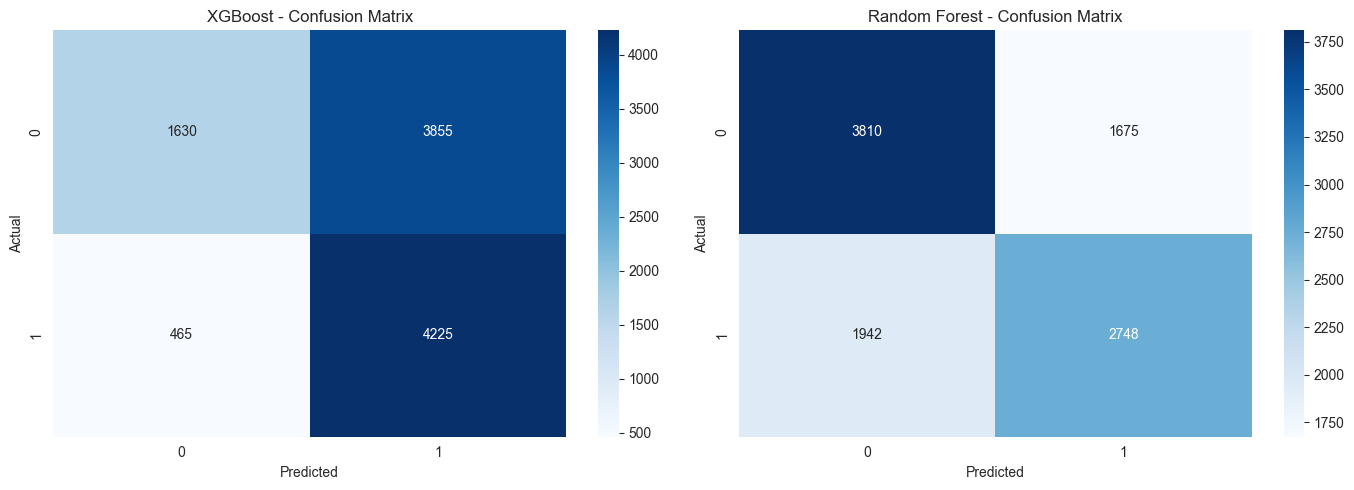

🏃 View run Final_Test_Evaluation at: http://localhost:5000/#/experiments/956909141126980178/runs/c99591f3e2b446e0b2d310abd6def936
🧪 View experiment at: http://localhost:5000/#/experiments/956909141126980178


In [11]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
xgb_test_pred = best_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, xgb_test_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
rf_test_pred = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Log confusion matrix plot to MLflow
with mlflow.start_run(run_name="Final_Test_Evaluation", nested=True):
    mlflow.log_artifact('confusion_matrices.png')

## 7. Summary

This notebook performed hyperparameter tuning for XGBoost and Random Forest models:

1. **Data**: Used the same feature engineering pipeline and feature selection as baseline
2. **Tuning Method**: RandomizedSearchCV with 30 iterations and 3-fold cross-validation
3. **Optimization Target**: F1 score (balances precision and recall for imbalanced data)
4. **Tracking**: All experiments logged to MLflow (hyperparameter-tuning experiment)

Run `mlflow ui --port 5000` to view all experiments and compare runs.

In [12]:
# Final summary table
print("="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {final_metrics['test_accuracy']:.4f}")
print(f"  F1 Score:  {final_metrics['test_f1']:.4f}")
print(f"  Precision: {final_metrics['test_precision']:.4f}")
print(f"  Recall:    {final_metrics['test_recall']:.4f}")
print(f"  ROC AUC:   {final_metrics['test_roc_auc']:.4f}")
print("\nAll runs tracked in MLflow: http://localhost:5000")

HYPERPARAMETER TUNING SUMMARY

Best Model: XGBoost

Test Set Performance:
  Accuracy:  0.5754
  F1 Score:  0.6617
  Precision: 0.5229
  Recall:    0.9009
  ROC AUC:   0.6982

All runs tracked in MLflow: http://localhost:5000


## 8. Feature Importance Analysis

Understanding which features contribute most to predictions helps interpret the model and validate that it's learning meaningful patterns.

Top 20 Most Important Features (XGBoost)
                                                                                               feature  importance
                                                                                         had_inpatient    0.106445
                                                                                          total_visits    0.102001
                                                                         discharge_disposition_Expired    0.062809
                                                                                     comorbidity_score    0.034545
                                                        discharge_disposition_Hospice_medical_facility    0.020299
                                                                    discharge_disposition_Hospice_home    0.017949
                                                                             diag_1_category_Neoplasms    0.017483
                                       

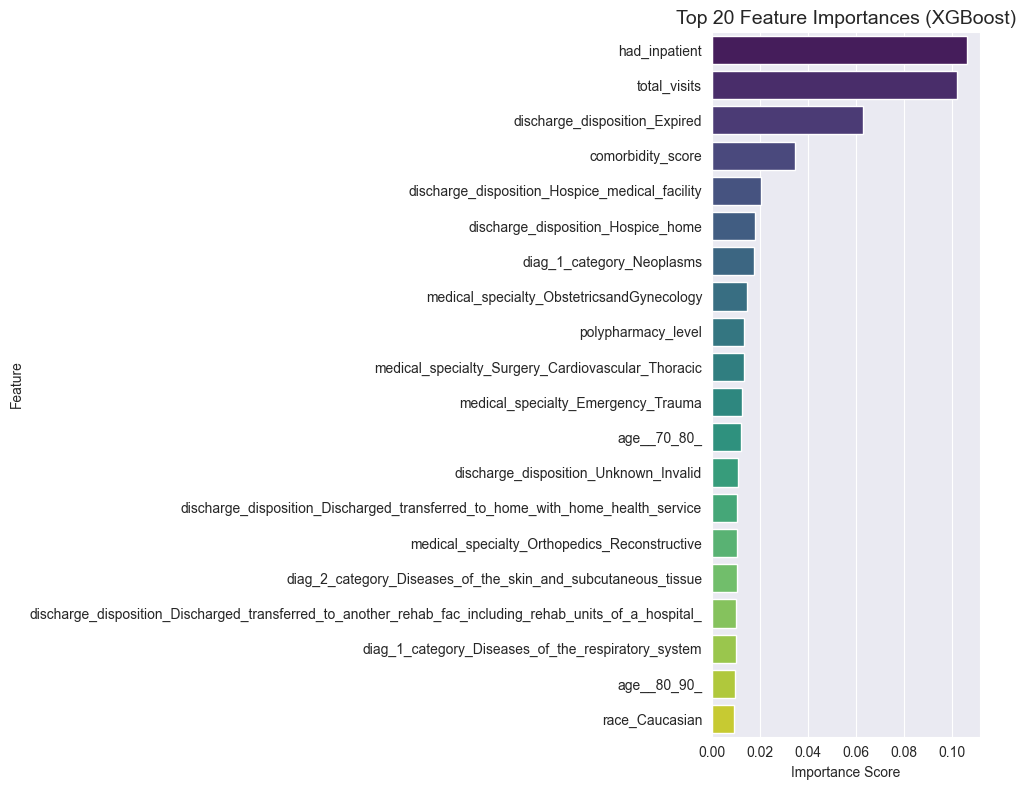

🏃 View run Feature_Importance_Analysis at: http://localhost:5000/#/experiments/956909141126980178/runs/782f369b2d8a4ce7b9b524988175e2b4
🧪 View experiment at: http://localhost:5000/#/experiments/956909141126980178


In [13]:
# Extract feature importances from best XGBoost model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20 features
print("Top 20 Most Important Features (XGBoost)")
print("=" * 50)
print(feature_importance.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = feature_importance.head(20)
sns.barplot(data=top_20, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=14)
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to MLflow
with mlflow.start_run(run_name="Feature_Importance_Analysis"):
    mlflow.log_artifact('feature_importance_xgb.png')
    feature_importance.to_csv('feature_importance.csv', index=False)
    mlflow.log_artifact('feature_importance.csv')
    mlflow.set_tag("analysis_type", "feature_importance")

## 9. Extended Hyperparameter Search

The initial search used limited iterations (15) and 2-fold CV for speed. Here we perform a more thorough search with 50 iterations and 5-fold CV for more robust results.

In [ ]:
# Extended search configuration
N_ITER_EXTENDED = 50
CV_FOLDS_EXTENDED = 5

print(f"Extended Search Configuration:")
print(f"  - Random iterations: {N_ITER_EXTENDED}")
print(f"  - CV folds: {CV_FOLDS_EXTENDED}")
print(f"  - Total fits: {N_ITER_EXTENDED * CV_FOLDS_EXTENDED}")
print("\nNote: This will take significantly longer than the initial search.")

In [ ]:
# Extended XGBoost hyperparameter search
print("Starting Extended XGBoost Tuning...")
print("=" * 50)

# Expanded parameter grid for thorough search
xgb_param_grid_extended = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5, 7],
    'gamma': [0, 0.05, 0.1, 0.2, 0.3],
    'scale_pos_weight': [1, 1.5, 2, 2.5, 3],
    'reg_alpha': [0, 0.01, 0.1, 1],  # L1 regularization
    'reg_lambda': [1, 1.5, 2, 3]     # L2 regularization
}

with mlflow.start_run(run_name="XGBoost_Extended_Tuning"):
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("search_type", "RandomizedSearchCV_Extended")
    mlflow.log_param("n_iter", N_ITER_EXTENDED)
    mlflow.log_param("cv_folds", CV_FOLDS_EXTENDED)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "extended_tuning")
    
    xgb_base_ext = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=2  # Leave some cores for CV parallelization
    )
    
    xgb_search_ext = RandomizedSearchCV(
        estimator=xgb_base_ext,
        param_distributions=xgb_param_grid_extended,
        n_iter=N_ITER_EXTENDED,
        scoring='f1',
        cv=CV_FOLDS_EXTENDED,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=2
    )
    
    xgb_search_ext.fit(X_train, y_train)
    
    best_xgb_ext = xgb_search_ext.best_estimator_
    best_xgb_params_ext = xgb_search_ext.best_params_
    
    # Log best parameters
    for param, value in best_xgb_params_ext.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    xgb_ext_val_pred = best_xgb_ext.predict(X_val)
    xgb_ext_val_proba = best_xgb_ext.predict_proba(X_val)[:, 1]
    
    xgb_ext_metrics = {
        'accuracy': accuracy_score(y_val, xgb_ext_val_pred),
        'f1': f1_score(y_val, xgb_ext_val_pred),
        'precision': precision_score(y_val, xgb_ext_val_pred),
        'recall': recall_score(y_val, xgb_ext_val_pred),
        'roc_auc': roc_auc_score(y_val, xgb_ext_val_proba),
        'cv_best_score': xgb_search_ext.best_score_
    }
    
    for metric_name, metric_value in xgb_ext_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    mlflow.xgboost.log_model(best_xgb_ext, "xgboost_extended_tuned")
    
    print(f"\nBest XGBoost Parameters (Extended Search):")
    for param, value in best_xgb_params_ext.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in xgb_ext_metrics.items():
        print(f"  {metric}: {value:.4f}")

## 10. Logistic Regression Hyperparameter Tuning

Logistic Regression is often overlooked for tuning, but optimizing the regularization strength (C) and penalty type can significantly improve performance.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression hyperparameter search space
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100],  # Inverse regularization strength
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],  # Solvers that support both L1 and L2
    'class_weight': ['balanced', None],
    'max_iter': [500, 1000, 2000]
}

print("Starting Logistic Regression Hyperparameter Tuning...")
print("=" * 50)

with mlflow.start_run(run_name="LogisticRegression_Tuning"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("search_type", "RandomizedSearchCV")
    mlflow.log_param("n_iter", N_ITER_EXTENDED)
    mlflow.log_param("cv_folds", CV_FOLDS_EXTENDED)
    mlflow.log_param("scoring", "f1")
    mlflow.set_tag("stage", "tuning")
    
    lr_base = LogisticRegression(random_state=RANDOM_STATE)
    
    lr_search = RandomizedSearchCV(
        estimator=lr_base,
        param_distributions=lr_param_grid,
        n_iter=N_ITER_EXTENDED,
        scoring='f1',
        cv=CV_FOLDS_EXTENDED,
        random_state=RANDOM_STATE,
        n_jobs=4,
        verbose=1
    )
    
    lr_search.fit(X_train, y_train)
    
    best_lr = lr_search.best_estimator_
    best_lr_params = lr_search.best_params_
    
    # Log best parameters
    for param, value in best_lr_params.items():
        mlflow.log_param(f"best_{param}", value)
    
    # Evaluate on validation set
    lr_val_pred = best_lr.predict(X_val)
    lr_val_proba = best_lr.predict_proba(X_val)[:, 1]
    
    lr_metrics = {
        'accuracy': accuracy_score(y_val, lr_val_pred),
        'f1': f1_score(y_val, lr_val_pred),
        'precision': precision_score(y_val, lr_val_pred),
        'recall': recall_score(y_val, lr_val_pred),
        'roc_auc': roc_auc_score(y_val, lr_val_proba),
        'cv_best_score': lr_search.best_score_
    }
    
    for metric_name, metric_value in lr_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    mlflow.sklearn.log_model(best_lr, "logistic_regression_tuned")
    
    print(f"\nBest Logistic Regression Parameters:")
    for param, value in best_lr_params.items():
        print(f"  {param}: {value}")
    print(f"\nValidation Metrics:")
    for metric, value in lr_metrics.items():
        print(f"  {metric}: {value:.4f}")

## 11. Threshold Optimization

By default, classifiers use 0.5 as the probability threshold. Optimizing this threshold can improve the precision/recall trade-off based on the specific use case requirements.

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve

# Use the best model from extended tuning (or fall back to original best)
try:
    model_for_threshold = best_xgb_ext
    model_name_thresh = "XGBoost (Extended)"
except NameError:
    model_for_threshold = best_xgb
    model_name_thresh = "XGBoost"

# Get probability predictions on validation set
y_val_proba = model_for_threshold.predict_proba(X_val)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, y_val_proba)

# Calculate F1 scores for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find optimal threshold for F1
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds_pr[optimal_idx_f1]

# Find threshold for balanced precision/recall (Youden's J statistic on ROC)
fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_proba)
j_scores = tpr - fpr
optimal_idx_j = np.argmax(j_scores)
optimal_threshold_j = thresholds_roc[optimal_idx_j]

print(f"Threshold Optimization Results ({model_name_thresh})")
print("=" * 60)
print(f"\nOptimal threshold for F1 Score: {optimal_threshold_f1:.4f}")
print(f"  - Precision: {precisions[optimal_idx_f1]:.4f}")
print(f"  - Recall: {recalls[optimal_idx_f1]:.4f}")
print(f"  - F1 Score: {f1_scores[optimal_idx_f1]:.4f}")
print(f"\nOptimal threshold (Youden's J): {optimal_threshold_j:.4f}")
print(f"  - TPR (Recall): {tpr[optimal_idx_j]:.4f}")
print(f"  - FPR: {fpr[optimal_idx_j]:.4f}")

In [ ]:
# Visualize threshold analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Precision-Recall Curve
axes[0].plot(recalls, precisions, 'b-', linewidth=2)
axes[0].axvline(x=recalls[optimal_idx_f1], color='r', linestyle='--', 
                label=f'Optimal F1 (t={optimal_threshold_f1:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: ROC Curve
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_score(y_val, y_val_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].scatter([fpr[optimal_idx_j]], [tpr[optimal_idx_j]], color='r', s=100, zorder=5,
                label=f"Optimal (t={optimal_threshold_j:.2f})")
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Plot 3: F1 Score vs Threshold
axes[2].plot(thresholds_pr, f1_scores, 'g-', linewidth=2)
axes[2].axvline(x=optimal_threshold_f1, color='r', linestyle='--',
                label=f'Optimal (t={optimal_threshold_f1:.2f}, F1={f1_scores[optimal_idx_f1]:.3f})')
axes[2].axvline(x=0.5, color='gray', linestyle=':', label='Default (t=0.5)')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score vs Classification Threshold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to MLflow
with mlflow.start_run(run_name="Threshold_Optimization"):
    mlflow.log_artifact('threshold_optimization.png')
    mlflow.log_param("optimal_threshold_f1", optimal_threshold_f1)
    mlflow.log_param("optimal_threshold_youden", optimal_threshold_j)
    mlflow.log_metric("optimal_f1_score", f1_scores[optimal_idx_f1])
    mlflow.set_tag("analysis_type", "threshold_optimization")

In [ ]:
# Compare default threshold (0.5) vs optimized threshold on test set
y_test_proba = model_for_threshold.predict_proba(X_test)[:, 1]

# Predictions with default threshold
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

# Predictions with optimized threshold
y_test_pred_optimized = (y_test_proba >= optimal_threshold_f1).astype(int)

# Calculate metrics for both
metrics_comparison = {
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC'],
    'Default (t=0.5)': [
        accuracy_score(y_test, y_test_pred_default),
        f1_score(y_test, y_test_pred_default),
        precision_score(y_test, y_test_pred_default),
        recall_score(y_test, y_test_pred_default),
        roc_auc_score(y_test, y_test_proba)
    ],
    f'Optimized (t={optimal_threshold_f1:.3f})': [
        accuracy_score(y_test, y_test_pred_optimized),
        f1_score(y_test, y_test_pred_optimized),
        precision_score(y_test, y_test_pred_optimized),
        recall_score(y_test, y_test_pred_optimized),
        roc_auc_score(y_test, y_test_proba)  # ROC AUC is threshold-independent
    ]
}

comparison_thresh_df = pd.DataFrame(metrics_comparison)
comparison_thresh_df['Improvement'] = (
    comparison_thresh_df[f'Optimized (t={optimal_threshold_f1:.3f})'] - 
    comparison_thresh_df['Default (t=0.5)']
).round(4)

print(f"\nTest Set: Default vs Optimized Threshold Comparison")
print("=" * 70)
print(comparison_thresh_df.to_string(index=False))

print(f"\n\nClassification Report with Optimized Threshold (t={optimal_threshold_f1:.3f}):")
print("-" * 60)
print(classification_report(y_test, y_test_pred_optimized, 
                           target_names=['No Readmission', 'Readmission']))

## 12. Extended Analysis Summary

This extended analysis added:
1. **Feature Importance Visualization** - Identifies key predictors of readmission
2. **Extended Hyperparameter Search** - 50 iterations with 5-fold CV for more robust results
3. **Logistic Regression Tuning** - Often overlooked but can be competitive with proper regularization
4. **Threshold Optimization** - Finds optimal probability cutoff for improved precision/recall trade-off

All results are tracked in MLflow for comparison and reproducibility.